# Spurious Currents Analysis

Stationary circular drop test:  
- Drop radius R=0.2, center (0.5, 0.5) in a 1×1 box  
- Equal densities: ρ=300, μ=0.1, σ=1.0  
- Laplace number La = ρσD/μ² = **12000**  
- Surface tension via CSF method  

Key metric: spurious capillary number **Ca\* = μ u_max / σ**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from mpi4py import MPI
import os

from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.coef import Coef as coef_c
from pysemtools.datatypes.field import Field as field_c

comm = MPI.COMM_WORLD

# Physics parameters
mu = 0.1
sigma = 1.0
La = 12000

# ======= DATA PATHS =======
# Point to the diagnostic rerun results downloaded from Dardel.
# Change this base path if your results are stored elsewhere.
RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath("analyze_spurious_currents.ipynb")),
                           "results")
DIAG_DIR = os.path.join(RESULTS_DIR, "spurious_diag_sigma1.0")
ANALYTIC_DIR = os.path.join(RESULTS_DIR, "spurious_diag_analytical_kappa")
THICK_DIR = os.path.join(RESULTS_DIR, "spurious_diag_thick_eps0.03")

# Field files from the diagnostic sigma=1.0 run (51 snapshots: f00000-f00050)
import glob
field_files = sorted(glob.glob(os.path.join(DIAG_DIR, "field0.f?????")))
N_SNAPSHOTS = len(field_files)
print(f"Found {N_SNAPSHOTS} field files in {DIAG_DIR}")
print(f"  First: {os.path.basename(field_files[0])}")
print(f"  Last:  {os.path.basename(field_files[-1])}")

## Load mesh and mass matrix weights

In [71]:
xyz_info = preadnek(field_files[0], comm)
msh = msh_c(comm, data=xyz_info)
coef = coef_c(msh, comm)

# Build element-local triangulation from the structured GLL grid.
# Each element's 8x8 GLL points (z-slice 0) are triangulated using their
# known local connectivity — no global Delaunay, so no long spurious
# triangles crossing element interiors that interpolate through phi=0.5.
n_elem = msh.x.shape[0]
lx = msh.x.shape[3]   # 8
ly = msh.x.shape[2]   # 8

x_all, y_all, triangles = [], [], []
offset = 0
for e in range(n_elem):
    x_all.append(msh.x[e, 0, :, :].flatten())
    y_all.append(msh.y[e, 0, :, :].flatten())
    for j in range(ly - 1):
        for i in range(lx - 1):
            p0 = offset + j * lx + i
            p1 = offset + j * lx + (i + 1)
            p2 = offset + (j + 1) * lx + i
            p3 = offset + (j + 1) * lx + (i + 1)
            triangles.append([p0, p1, p3])
            triangles.append([p0, p3, p2])
    offset += lx * ly

x = np.concatenate(x_all)
y = np.concatenate(y_all)
triang = tri.Triangulation(x, y, np.array(triangles))
print(f"{n_elem} elements, {len(x)} points, {len(triangles)} triangles")

2026-02-20 13:42:09,276 - preadnek - INFO - Reading file: field0.f00000
2026-02-20 13:42:09,344 - preadnek - INFO - Elapsed time: 0.06809900000007474s
2026-02-20 13:42:09,358 - Mesh - INFO - Initializing Mesh object from HexaData object.
2026-02-20 13:42:09,363 - Mesh - INFO - Initializing common attributes.
2026-02-20 13:42:09,364 - Mesh - INFO - Getting vertices
2026-02-20 13:42:09,368 - Mesh - INFO - Getting edge centers
2026-02-20 13:42:09,384 - Mesh - INFO - Getting facet centers
2026-02-20 13:42:09,390 - Mesh - INFO - Mesh object initialized.
2026-02-20 13:42:09,392 - Mesh - INFO - Mesh data is of type: float64
2026-02-20 13:42:09,396 - Mesh - INFO - Elapsed time: 0.03863499999988562s
2026-02-20 13:42:09,405 - Coef - INFO - Initializing Coef object
2026-02-20 13:42:09,407 - Coef - INFO - Getting derivative matrices
2026-02-20 13:42:09,419 - Coef - INFO - Calculating the components of the jacobian
2026-02-20 13:42:09,441 - Coef - INFO - Calculating the jacobian determinant and inv

In [72]:
# Inspect field contents and z-coordinate structure
data_check = preadnek(field_files[-1], comm)
fld_check = field_c(comm, data=data_check)
print(f"vel:  {len(fld_check.fields['vel'])} component(s)")
print(f"pres: {len(fld_check.fields['pres'])} component(s)")
print(f"temp: {len(fld_check.fields['temp'])} component(s)")
print(f"scal: {len(fld_check.fields['scal'])} component(s)  <- phase field")
print()

# Check z-coordinates at each z-index (element 0 as example)
print("z values at each z-index for element 0:")
for iz in range(msh.z.shape[1]):
    z_vals = msh.z[0, iz, :, :]
    print(f"  z-index {iz}: z = {z_vals.mean():.6f} (min={z_vals.min():.6f}, max={z_vals.max():.6f})")

# Check if phi varies across z for a point near the interface
print()
phi_check = fld_check.fields["scal"][0]
print("phi at element 0, (iy=4, ix=4) across z-levels:")
for iz in range(phi_check.shape[1]):
    print(f"  z-index {iz}: phi = {phi_check[0, iz, 4, 4]:.6f}")

2026-02-20 13:42:09,666 - preadnek - INFO - Reading file: field0.f00011
2026-02-20 13:42:09,701 - preadnek - INFO - Elapsed time: 0.03537099999994098s
2026-02-20 13:42:09,713 - Field - INFO - Initializing Field object from HexaData
2026-02-20 13:42:09,720 - Field - INFO - Field object initialized
2026-02-20 13:42:09,722 - Field - INFO - Elapsed time: 0.009020999999847845s
vel:  3 component(s)
pres: 1 component(s)
temp: 0 component(s)
scal: 1 component(s)  <- phase field

z values at each z-index for element 0:
  z-index 0: z = -0.100000 (min=-0.100000, max=-0.100000)
  z-index 1: z = -0.093587 (min=-0.093587, max=-0.093587)
  z-index 2: z = -0.079585 (min=-0.079585, max=-0.079585)
  z-index 3: z = -0.060465 (min=-0.060465, max=-0.060465)
  z-index 4: z = -0.039535 (min=-0.039535, max=-0.039535)
  z-index 5: z = -0.020415 (min=-0.020415, max=-0.020415)
  z-index 6: z = -0.006413 (min=-0.006413, max=-0.006413)
  z-index 7: z = 0.000000 (min=0.000000, max=0.000000)

phi at element 0, (iy=

## Part A: Flow field at final time

Shows where the spurious currents are located relative to the interface.

In [73]:
data_final = preadnek(field_files[-1], comm)
fld_final = field_c(comm, data=data_final)
t_final = fld_final.t

# z-slice 0 matches the element-local triangulation built above
phi    = fld_final.fields["scal"][0][:, 0, :, :].flatten()
u      = fld_final.fields["vel"][0][:, 0, :, :].flatten()
v      = fld_final.fields["vel"][1][:, 0, :, :].flatten()
vel_mag = np.sqrt(u**2 + v**2)

print(f"t = {t_final:.4f}")
print(f"phi range: [{phi.min():.4f}, {phi.max():.4f}]")
print(f"u_max = {vel_mag.max():.4e},  Ca* = {mu * vel_mag.max() / sigma:.4e}")

2026-02-20 13:42:09,754 - preadnek - INFO - Reading file: field0.f00011
2026-02-20 13:42:09,798 - preadnek - INFO - Elapsed time: 0.04310000000077707s
2026-02-20 13:42:09,808 - Field - INFO - Initializing Field object from HexaData
2026-02-20 13:42:09,818 - Field - INFO - Field object initialized
2026-02-20 13:42:09,819 - Field - INFO - Elapsed time: 0.010631000000103086s
t = 0.0101
phi range: [-0.0000, 1.0000]
u_max = 1.7689e-02,  Ca* = 1.7689e-03


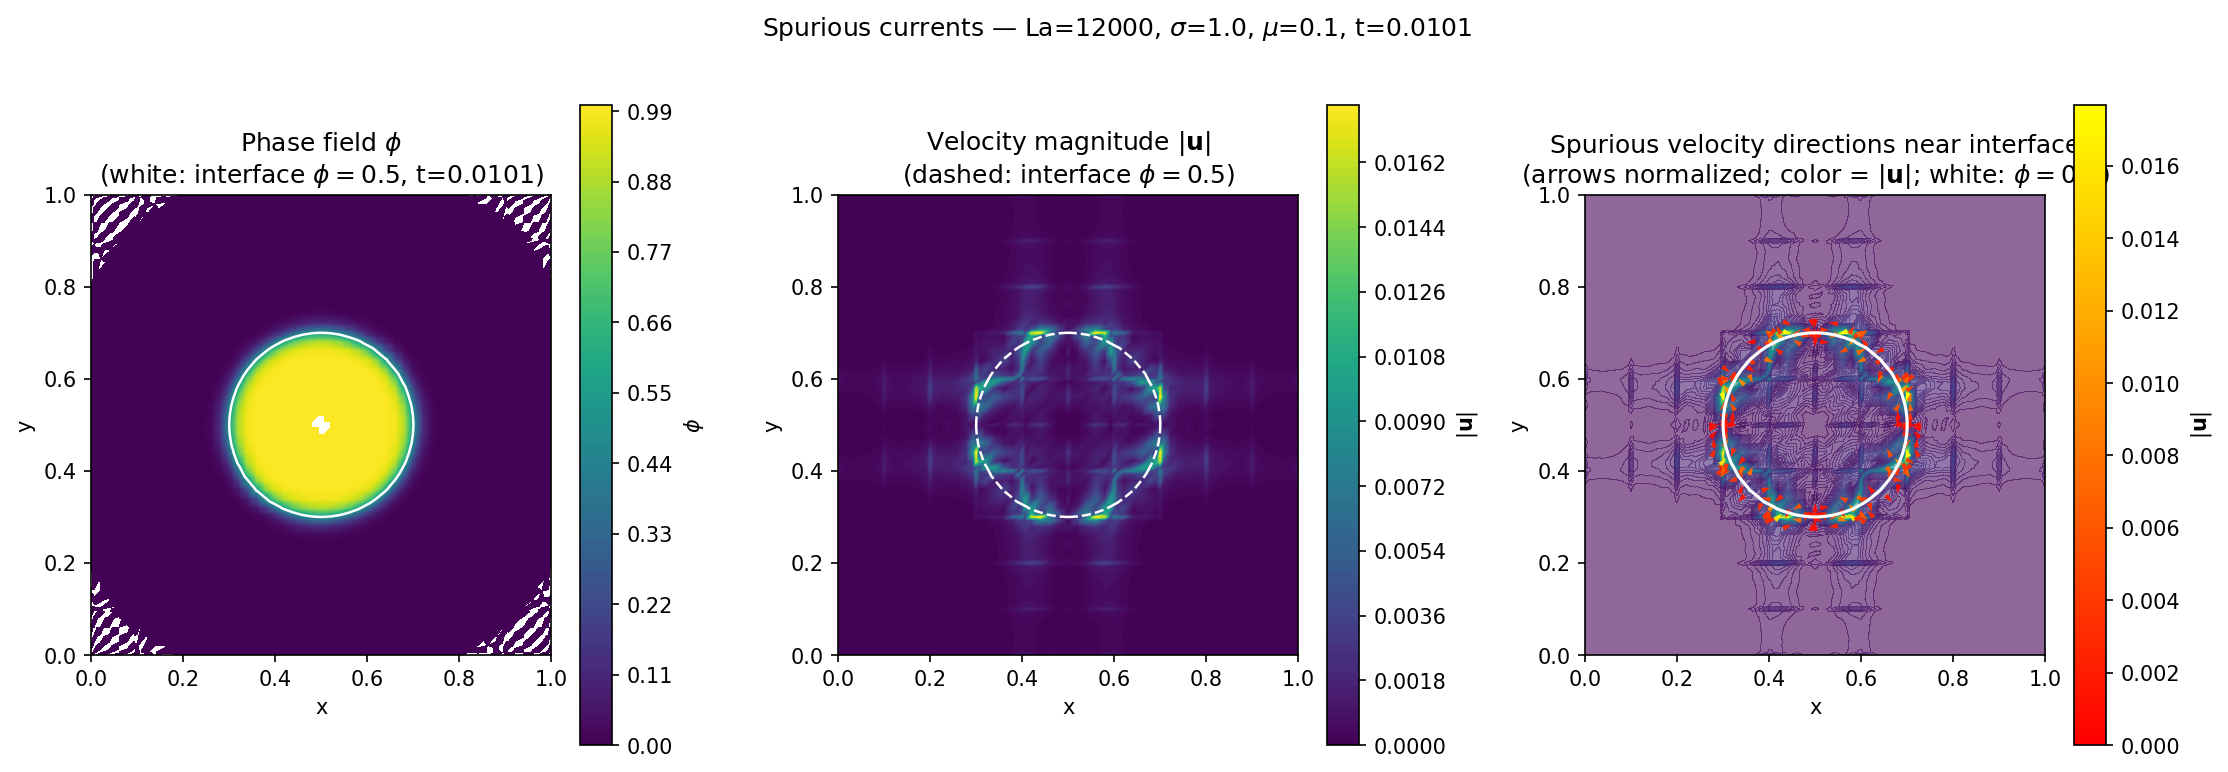

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

# --- Plot 1: Phase field ---
# viridis has no white anywhere in [0,1]; the interface is marked by a contour.
ax = axes[0]
c = ax.tricontourf(triang, phi, levels=100, cmap="RdBu_r", vmin=0, vmax=1)
ax.tricontour(triang, phi, levels=[0.5], colors="w", linewidths=1.2)
fig.colorbar(c, ax=ax, label=r"$\phi$")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Phase field $\\phi$\n(white: interface $\\phi=0.5$, t={t_final:.4f})")

# --- Plot 2: Velocity magnitude with interface contour ---
ax = axes[1]
c = ax.tricontourf(triang, vel_mag, levels=100, cmap="viridis")
ax.tricontour(triang, phi, levels=[0.5], colors="w", linewidths=1.2,
              linestyles="--")
fig.colorbar(c, ax=ax, label=r"$|\mathbf{u}|$")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Velocity magnitude $|\mathbf{u}|$"
             + "\n(dashed: interface $\\phi=0.5$)")

# --- Plot 3: Normalized velocity vectors near the interface ---
near = (phi > 0.05) & (phi < 0.95)
step = 3
idx = np.where(near)[0][::step]
xq, yq = x[idx], y[idx]
uq, vq = u[idx], v[idx]
magq   = vel_mag[idx]
u_norm = uq / (magq + 1e-30)
v_norm = vq / (magq + 1e-30)

ax = axes[2]
ax.tricontourf(triang, vel_mag, levels=100, cmap="viridis", alpha=0.6)
q = ax.quiver(xq, yq, u_norm, v_norm, magq,
              cmap="autumn", clim=[0, vel_mag.max()],
              scale=50, width=0.004, pivot="mid")
fig.colorbar(q, ax=ax, label=r"$|\mathbf{u}|$")
ax.tricontour(triang, phi, levels=[0.5], colors="white", linewidths=1.5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Spurious velocity directions near interface\n"
             r"(arrows normalized; color = $|\mathbf{u}|$; white: $\phi=0.5$)")

plt.suptitle(
    f"Spurious currents — La={La}, $\\sigma$={sigma}, $\\mu$={mu},"
    f" t={t_final:.4f}",
    y=1.02)
plt.tight_layout()
plt.savefig("spurious_currents_flow_field.png", dpi=150, bbox_inches="tight")
plt.show()

## Part B: Ca*(t) over all snapshots

The spurious capillary number **Ca\* = μ u_max / σ** measures the magnitude of
spurious currents. For a well-behaved CDI method it should remain small and
ideally plateau.

In [75]:
times = []
u_max_vals = []

for fname in field_files:
    data = preadnek(fname, comm)
    fld = field_c(comm, data=data)
    u_snap = fld.fields["vel"][0][:, 0, :, :]
    v_snap = fld.fields["vel"][1][:, 0, :, :]
    vel_mag_snap = np.sqrt(u_snap**2 + v_snap**2)
    times.append(fld.t)
    u_max_vals.append(float(np.max(vel_mag_snap)))
    print(f"  t={fld.t:.5f}  u_max={u_max_vals[-1]:.4e}")

times = np.array(times)
u_max_vals = np.array(u_max_vals)
Ca_star = mu * u_max_vals / sigma

print(f"\nFinal Ca* = {Ca_star[-1]:.4e}")

2026-02-20 13:42:14,089 - preadnek - INFO - Reading file: field0.f00000
2026-02-20 13:42:14,118 - preadnek - INFO - Elapsed time: 0.02899600000000646s
2026-02-20 13:42:14,126 - Field - INFO - Initializing Field object from HexaData
2026-02-20 13:42:14,134 - Field - INFO - Field object initialized
2026-02-20 13:42:14,139 - Field - INFO - Elapsed time: 0.012789999999768042s
  t=0.00000  u_max=0.0000e+00
2026-02-20 13:42:14,143 - preadnek - INFO - Reading file: field0.f00001
2026-02-20 13:42:14,182 - preadnek - INFO - Elapsed time: 0.03895199999988108s
2026-02-20 13:42:14,184 - Field - INFO - Initializing Field object from HexaData
2026-02-20 13:42:14,209 - Field - INFO - Field object initialized
2026-02-20 13:42:14,212 - Field - INFO - Elapsed time: 0.027510000000802393s
  t=0.00100  u_max=1.9602e-03
2026-02-20 13:42:14,215 - preadnek - INFO - Reading file: field0.f00002
2026-02-20 13:42:14,239 - preadnek - INFO - Elapsed time: 0.023478000000068278s
2026-02-20 13:42:14,246 - Field - INFO

In [ ]:
D = 0.4  # drop diameter
t_star = sigma * times / (mu * D)  # non-dimensional time t* = σt/(μD)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Dimensional plot
ax = axes[0]
ax.plot(times, Ca_star, "o-", label=f"La={La}, σ={sigma}, μ={mu}")
ax.set_xlabel("time $t$")
ax.set_ylabel(r"$Ca^* = \mu\, u_{\max} / \sigma$")
ax.set_title("Spurious capillary number $Ca^*$ vs time")
ax.legend()
ax.grid(True)

# Non-dimensional plot
ax = axes[1]
ax.plot(t_star, Ca_star, "o-", label=f"La={La}, σ={sigma}, μ={mu}")
ax.set_xlabel(r"$t^* = \sigma t / (\mu D)$")
ax.set_ylabel(r"$Ca^\infty = \mu\, u_{\max} / \sigma$")
ax.set_title(r"Spurious $Ca^\infty$ vs non-dimensional time $t^*$")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("Ca_star_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Part C: Cross-check Ekin from fields vs ekin.csv

In [ ]:
ekin_csv = np.genfromtxt(os.path.join(DIAG_DIR, "ekin.csv"), delimiter=",", comments="#")
t_csv    = ekin_csv[:, 0]
Ekin_csv = ekin_csv[:, 1]

# Compute Ekin from field files (use first 12 for quick cross-check)
# Ekin = 0.5 * integral(|u|^2 dV) / V = 0.5 * sum(|u|^2 * B) / sum(B)
V = float(np.sum(coef.B))
Ekin_fields = []
times_check = []

for fname in field_files[:12]:
    data = preadnek(fname, comm)
    fld = field_c(comm, data=data)
    u_snap = fld.fields["vel"][0]
    v_snap = fld.fields["vel"][1]
    w_snap = fld.fields["vel"][2] if len(fld.fields["vel"]) > 2 else np.zeros_like(u_snap)
    uu = u_snap**2 + v_snap**2 + w_snap**2
    Ekin_fields.append(0.5 * float(np.sum(uu * coef.B)) / V)
    times_check.append(fld.t)

Ekin_fields = np.array(Ekin_fields)
times_check = np.array(times_check)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.plot(times_check, Ekin_fields, "o-", label="from field files")
ax.plot(t_csv, Ekin_csv, "s--", markersize=2, label="ekin.csv")
ax.set_xlabel("time $t$")
ax.set_ylabel("kinetic energy $E_{kin}$")
ax.set_title("Ekin cross-check: field files vs ekin.csv")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Ekin_crosscheck.png", dpi=150, bbox_inches="tight")
plt.show()

# Print comparison at matching times
print("Time     Ekin (fields)    Ekin (csv)       rel. diff")
for tc, ef in zip(times_check, Ekin_fields):
    idx = np.argmin(np.abs(t_csv - tc))
    e_c = Ekin_csv[idx]
    if e_c > 0:
        rel = abs(ef - e_c) / e_c
        print(f"{tc:.4f}   {ef:.6e}   {e_c:.6e}   {rel:.2e}")
    else:
        print(f"{tc:.4f}   {ef:.6e}   {e_c:.6e}   (zero)")

## Part D: Multi-sigma comparison — Ca∞ vs t*

Read `ekin.csv` (column 4 = u_max) from each sigma run directory and plot
Ca∞ = μ·u_max/σ versus t* = σ·t/(μ·D) for all σ values.

Run directories are named `sigma_10.0/`, `sigma_1.0/`, etc. and are created by
`run_sigma_sweep.sh`.  Only directories with an existing `ekin.csv` are plotted.

In [ ]:
import os

# Physics parameters (fixed for all runs)
mu_sweep = 0.1
D_sweep  = 0.4
rho      = 300.0

sigma_values = [10.0, 1.0, 0.5, 0.1, 0.05, 0.01]

# Directory where this notebook lives; sigma subdirs are relative to it
notebook_dir = os.path.dirname(os.path.abspath("analyze_spurious_currents.ipynb"))

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

for sig in sigma_values:
    csv_path = os.path.join(notebook_dir, f"sigma_{sig}", "ekin.csv")
    if not os.path.exists(csv_path):
        print(f"Skipping σ={sig}: {csv_path} not found")
        continue

    data = np.genfromtxt(csv_path, delimiter=",", comments="#")
    if data.ndim == 1:
        data = data[np.newaxis, :]  # single-row file

    t_col    = data[:, 0]
    u_max_col = data[:, 3]   # column 4 added by the Fortran change

    t_star_col  = sig * t_col / (mu_sweep * D_sweep)
    Ca_inf_col  = mu_sweep * u_max_col / sig
    La_val = rho * sig * D_sweep / (mu_sweep**2)

    ax.semilogy(t_star_col, np.maximum(Ca_inf_col, 1e-20),
                label=f"σ={sig}, La={La_val:.0f}")

ax.set_xlabel(r"$t^* = \sigma t / (\mu D)$")
ax.set_ylabel(r"$Ca^\infty = \mu\, u_{\max} / \sigma$")
ax.set_title("Spurious Capillary Number vs Non-Dimensional Time\n"
             "for multiple surface tension coefficients")
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.savefig("Ca_inf_sigma_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## SEM Derivative Helpers

Utility functions for computing gradient and divergence on the spectral element
mesh using `pysemtools`' `coef.dudxyz()` method.  These replicate the Fortran
`grad()` and `div()` operators so we can compute curvature, normals, and surface
tension forces from field files in post-processing.

In [ ]:
def sem_grad(phi, coef):
    """Compute gradient of a scalar field on the SEM mesh.
    
    Parameters
    ----------
    phi : ndarray, shape (nelv, lz, ly, lx)
    coef : pysemtools Coef object
    
    Returns
    -------
    dphidx, dphidy, dphidz : ndarrays, same shape as phi
    """
    dphidx = coef.dudxyz(phi, coef.drdx, coef.dsdx, coef.dtdx)
    dphidy = coef.dudxyz(phi, coef.drdy, coef.dsdy, coef.dtdy)
    dphidz = coef.dudxyz(phi, coef.drdz, coef.dsdz, coef.dtdz)
    return dphidx, dphidy, dphidz


def sem_div(fx, fy, fz, coef):
    """Compute divergence of a vector field on the SEM mesh.
    
    Parameters
    ----------
    fx, fy, fz : ndarrays, shape (nelv, lz, ly, lx)
    coef : pysemtools Coef object
    
    Returns
    -------
    div_f : ndarray, same shape
    """
    dfxdx = coef.dudxyz(fx, coef.drdx, coef.dsdx, coef.dtdx)
    dfydy = coef.dudxyz(fy, coef.drdy, coef.dsdy, coef.dtdy)
    dfzdz = coef.dudxyz(fz, coef.drdz, coef.dsdz, coef.dtdz)
    return dfxdx + dfydy + dfzdz


def compute_curvature(phi_4d, coef, eps_norm=1e-12):
    """Compute CSF curvature kappa = div(grad(phi)/|grad(phi)|).
    
    Returns kappa, gradphi_mag, nx, ny, nz  (all shape nelv, lz, ly, lx).
    Note: element-local (no GS averaging), which reveals boundary artifacts.
    """
    dphidx, dphidy, dphidz = sem_grad(phi_4d, coef)
    gradphi_mag = np.sqrt(dphidx**2 + dphidy**2 + dphidz**2)
    
    mask = gradphi_mag > eps_norm
    nx = np.where(mask, dphidx / gradphi_mag, 0.0)
    ny = np.where(mask, dphidy / gradphi_mag, 0.0)
    nz = np.where(mask, dphidz / gradphi_mag, 0.0)
    
    kappa = sem_div(nx, ny, nz, coef)
    return kappa, gradphi_mag, nx, ny, nz

print("SEM derivative helpers loaded.")

## Part E: Curvature Field Analysis

The CSF method computes curvature as $\kappa = \nabla \cdot \hat{n}$ where
$\hat{n} = \nabla\phi / |\nabla\phi|$.  For a circle of radius $R = 0.2$
the analytical curvature is $\kappa = 1/R = 5.0$.

Deviations from this value — especially at element boundaries — are the
primary driver of spurious currents.

In [ ]:
# Pick a snapshot (adjust index as needed after the diagnostic rerun)
snap_idx = min(10, len(field_files) - 1)
data_snap = preadnek(field_files[snap_idx], comm)
fld_snap = field_c(comm, data=data_snap)
phi_4d = fld_snap.fields["scal"][0]
t_snap = fld_snap.t
print(f"Snapshot: {field_files[snap_idx]}, t = {t_snap:.5f}")

# Compute curvature
kappa, gradphi_mag, nx, ny, nz = compute_curvature(phi_4d, coef)

# Flatten z-slice 0 for plotting
kappa_flat = kappa[:, 0, :, :].flatten()
gm_flat = gradphi_mag[:, 0, :, :].flatten()
phi_flat = phi_4d[:, 0, :, :].flatten()

# Interface mask: points where |grad(phi)| is significant
interface_mask = gm_flat > 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Plot 1: Curvature field (clipped)
ax = axes[0]
levels = np.linspace(-15, 15, 100)
c = ax.tricontourf(triang, np.clip(kappa_flat, -15, 15), levels=levels, cmap="RdBu_r")
ax.tricontour(triang, phi_flat, levels=[0.5], colors='k', linewidths=1.5)
fig.colorbar(c, ax=ax, label=r"$\kappa$")
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(rf"Curvature $\kappa = \nabla \cdot \hat{{n}}$, $t={t_snap:.4f}$")

# Plot 2: Curvature at interface points, colored by deviation from 1/R
ax = axes[1]
if np.any(interface_mask):
    sc = ax.scatter(x[interface_mask], y[interface_mask],
                    c=kappa_flat[interface_mask], cmap="RdBu_r",
                    vmin=0, vmax=10, s=4, edgecolors='none')
    fig.colorbar(sc, ax=ax, label=r"$\kappa$")
    ax.axhline(0.5, color='gray', alpha=0.3, lw=0.5)
    ax.axvline(0.5, color='gray', alpha=0.3, lw=0.5)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"$\kappa$ at interface (analytical = 5.0)")

# Plot 3: Histogram of kappa at interface
ax = axes[2]
if np.any(interface_mask):
    ax.hist(kappa_flat[interface_mask], bins=100, range=(-15, 25), alpha=0.7)
    ax.axvline(x=5.0, color='r', linestyle='--', lw=2, label=r'analytical $1/R = 5.0$')
    k_if = kappa_flat[interface_mask]
    ax.set_title(f"$\\kappa$ histogram at interface\n"
                 f"mean={np.mean(k_if):.2f}, std={np.std(k_if):.2f}, "
                 f"range=[{np.min(k_if):.1f}, {np.max(k_if):.1f}]")
ax.set_xlabel(r"$\kappa$"); ax.legend()

plt.suptitle(f"Curvature analysis at t = {t_snap:.4f}", y=1.02)
plt.tight_layout()
plt.savefig("curvature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Element boundary vs interior curvature comparison
# This reveals whether curvature errors concentrate at element interfaces.
kappa_2d = kappa[:, 0, :, :]      # (nelv, ly, lx)
gm_2d = gradphi_mag[:, 0, :, :]

kappa_interior_pts, kappa_boundary_pts = [], []

for e in range(n_elem):
    k_e = kappa_2d[e]
    gm_e = gm_2d[e]
    # Interior: not on any element edge
    mask_int = gm_e[1:-1, 1:-1].flatten() > 1.0
    k_int = k_e[1:-1, 1:-1].flatten()
    if np.any(mask_int):
        kappa_interior_pts.extend(k_int[mask_int])
    # Boundary: on element edges (i=0, i=lx-1, j=0, j=ly-1)
    k_bnd = np.concatenate([k_e[0,:], k_e[-1,:], k_e[1:-1,0], k_e[1:-1,-1]])
    gm_bnd = np.concatenate([gm_e[0,:], gm_e[-1,:], gm_e[1:-1,0], gm_e[1:-1,-1]])
    mask_bnd = gm_bnd > 1.0
    if np.any(mask_bnd):
        kappa_boundary_pts.extend(k_bnd[mask_bnd])

kappa_interior_pts = np.array(kappa_interior_pts)
kappa_boundary_pts = np.array(kappa_boundary_pts)

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
bins = np.linspace(-15, 25, 120)
ax.hist(kappa_interior_pts, bins=bins, alpha=0.6, density=True,
        label=f"interior ({len(kappa_interior_pts)} pts, "
              f"std={np.std(kappa_interior_pts):.2f})")
ax.hist(kappa_boundary_pts, bins=bins, alpha=0.6, density=True,
        label=f"element boundary ({len(kappa_boundary_pts)} pts, "
              f"std={np.std(kappa_boundary_pts):.2f})")
ax.axvline(5.0, color='r', linestyle='--', lw=2, label=r"analytical $1/R$")
ax.set_xlabel(r"$\kappa$")
ax.set_ylabel("density")
ax.set_title("Curvature: element interior vs element boundary nodes\n"
             "(wider distribution at boundaries = element discontinuity artifact)")
ax.legend()
plt.tight_layout()
plt.savefig("curvature_boundary_vs_interior.png", dpi=150, bbox_inches="tight")
plt.show()

## Part F: Interface Normal Vector Field

Compare computed normals $\hat{n} = \nabla\phi/|\nabla\phi|$ against the
analytical radial direction from the drop center (0.5, 0.5).  Angular
deviation indicates discretization error in the normal field, which feeds
directly into the curvature via $\kappa = \nabla\cdot\hat{n}$.

In [ ]:
nx_flat = nx[:, 0, :, :].flatten()
ny_flat = ny[:, 0, :, :].flatten()

# Analytical normal: radial from (0.5, 0.5)
rx = x - 0.5
ry = y - 0.5
r_mag = np.sqrt(rx**2 + ry**2)
nx_anal = rx / (r_mag + 1e-30)
ny_anal = ry / (r_mag + 1e-30)

# Angular error (degrees)
dot_prod = nx_flat * nx_anal + ny_flat * ny_anal
dot_prod = np.clip(dot_prod, -1, 1)
angle_err = np.degrees(np.arccos(dot_prod))

# Near-interface points for quiver
near = interface_mask
step = 4
idx = np.where(near)[0][::step]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Plot 1: Computed vs analytical normals
ax = axes[0]
ax.tricontourf(triang, phi_flat, levels=50, cmap="RdBu_r", alpha=0.3)
ax.quiver(x[idx], y[idx], nx_flat[idx], ny_flat[idx],
          scale=40, width=0.003, color='black', label='computed')
ax.quiver(x[idx], y[idx], nx_anal[idx], ny_anal[idx],
          scale=40, width=0.003, color='red', alpha=0.5, label='analytical')
ax.tricontour(triang, phi_flat, levels=[0.5], colors='white', linewidths=2)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Normal vectors: computed (black) vs analytical (red)")
ax.legend(fontsize=9)

# Plot 2: Angular error at interface
ax = axes[1]
if np.any(near):
    sc = ax.scatter(x[near], y[near], c=angle_err[near],
                    cmap="hot_r", vmin=0, vmax=max(5, np.percentile(angle_err[near], 95)),
                    s=4, edgecolors='none')
    fig.colorbar(sc, ax=ax, label="angular error (degrees)")
ax.tricontour(triang, phi_flat, levels=[0.5], colors='cyan', linewidths=1.5)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Normal vector angular error at interface\n"
             f"mean={np.mean(angle_err[near]):.2f}°, "
             f"max={np.max(angle_err[near]):.1f}°")

plt.tight_layout()
plt.savefig("normal_vector_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Part G: Surface Tension Force Distribution

$\mathbf{F}_{ST} = \sigma\,\kappa\,\nabla\phi$.  For an exact solution, this
force is purely in the normal direction and exactly balanced by the pressure
gradient.  Any tangential component or force imbalance drives spurious currents.

In [ ]:
# Compute surface tension force F_ST = sigma * kappa * grad(phi)
dphidx, dphidy, dphidz = sem_grad(phi_4d, coef)
Fst_x = sigma * kappa * dphidx
Fst_y = sigma * kappa * dphidy
Fst_mag = np.sqrt(Fst_x**2 + Fst_y**2)

Fst_mag_flat = Fst_mag[:, 0, :, :].flatten()
Fst_x_flat = Fst_x[:, 0, :, :].flatten()
Fst_y_flat = Fst_y[:, 0, :, :].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Plot 1: Force magnitude (log scale)
ax = axes[0]
log_fst = np.log10(Fst_mag_flat + 1e-30)
c = ax.tricontourf(triang, log_fst, levels=50, cmap="hot")
ax.tricontour(triang, phi_flat, levels=[0.5], colors='cyan', linewidths=1.5)
fig.colorbar(c, ax=ax, label=r"$\log_{10} |F_{ST}|$")
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(rf"Surface tension force magnitude $|F_{{ST}}|$, $t={t_snap:.4f}$")

# Plot 2: Force vectors near interface with tangential component highlighted
ax = axes[1]
ax.tricontourf(triang, phi_flat, levels=50, cmap="RdBu_r", alpha=0.3)
step2 = 5
idx2 = np.where(near)[0][::step2]
q = ax.quiver(x[idx2], y[idx2], Fst_x_flat[idx2], Fst_y_flat[idx2],
              Fst_mag_flat[idx2], cmap="hot", scale=None, width=0.003)
fig.colorbar(q, ax=ax, label=r"$|F_{ST}|$")
ax.tricontour(triang, phi_flat, levels=[0.5], colors='white', linewidths=1.5)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"$F_{ST}$ vectors near interface")

plt.tight_layout()
plt.savefig("surface_tension_force.png", dpi=150, bbox_inches="tight")
plt.show()

# Decompose into normal and tangential components
if np.any(near):
    F_normal = Fst_x_flat[near] * nx_anal[near] + Fst_y_flat[near] * ny_anal[near]
    F_tang_x = Fst_x_flat[near] - F_normal * nx_anal[near]
    F_tang_y = Fst_y_flat[near] - F_normal * ny_anal[near]
    F_tang_mag = np.sqrt(F_tang_x**2 + F_tang_y**2)
    print(f"|F_normal| mean: {np.mean(np.abs(F_normal)):.4e}")
    print(f"|F_tang|   mean: {np.mean(F_tang_mag):.4e}")
    print(f"Tangential/Normal ratio: {np.mean(F_tang_mag)/np.mean(np.abs(F_normal)):.4e}")

## Part H: Phase Field Quality

Track $\phi_{\min}$ and $\phi_{\max}$ over time.  Violations of $[0,1]$
indicate numerical overshoot/undershoot in the advection scheme, which can
corrupt curvature computation.

In [ ]:
# Read the expanded diagnostic CSV (10 columns)
# Columns: t, Ekin, enst, u_max, kappa_max, kappa_min, kappa_rms, Fst_max, phi_min, phi_max
diag = np.genfromtxt(os.path.join(DIAG_DIR, "ekin.csv"), delimiter=",", comments="#")
t_d = diag[:, 0]
ncols = diag.shape[1]
print(f"ekin.csv: {diag.shape[0]} rows, {ncols} columns")

if ncols >= 10:
    phi_min_ts = diag[:, 8]
    phi_max_ts = diag[:, 9]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    ax = axes[0]
    ax.plot(t_d, phi_min_ts, 'b-', label=r"$\phi_{\min}$")
    ax.plot(t_d, phi_max_ts, 'r-', label=r"$\phi_{\max}$")
    ax.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("t"); ax.set_ylabel(r"$\phi$ bounds"); ax.legend()
    ax.set_title(r"Phase field min/max vs time (violations outside $[0,1]$)")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    violation = np.maximum(0, -phi_min_ts) + np.maximum(0, phi_max_ts - 1.0)
    ax.semilogy(t_d, np.maximum(violation, 1e-16))
    ax.set_xlabel("t"); ax.set_ylabel("total bound violation")
    ax.set_title("Phase field bound violation magnitude")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("phase_field_quality.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("CSV has old format (3 columns). Rerun with diagnostic F90 to get phase bounds.")

## Part I: Pressure Jump (Laplace Pressure Check)

For a stationary drop, the Laplace condition requires
$\Delta p = p_{\text{inside}} - p_{\text{outside}} = \sigma / R$.
With $\sigma=1.0$, $R=0.2$: $\Delta p = 5.0$.

Deviation from this indicates force-pressure imbalance.

In [ ]:
# Pressure analysis from a field snapshot
R = 0.2
Delta_p_analytical = sigma / R  # = 5.0

p_4d = fld_snap.fields["pres"][0]
p_flat = p_4d[:, 0, :, :].flatten()

# Pressure inside and outside the drop
p_inside = p_flat[phi_flat > 0.9]
p_outside = p_flat[phi_flat < 0.1]

Delta_p_measured = np.mean(p_inside) - np.mean(p_outside)
print(f"p_inside:  mean={np.mean(p_inside):.4f}, std={np.std(p_inside):.4f}")
print(f"p_outside: mean={np.mean(p_outside):.4f}, std={np.std(p_outside):.4f}")
print(f"Delta_p measured:   {Delta_p_measured:.4f}")
print(f"Delta_p analytical: {Delta_p_analytical:.4f}")
print(f"Relative error:     {abs(Delta_p_measured - Delta_p_analytical)/Delta_p_analytical:.4e}")

# Pressure along y = 0.5 (horizontal line through center)
# Use direct GLL point sampling: find points closest to y=0.5
y_tol = 0.015  # tolerance for "near y=0.5"
line_mask = np.abs(y - 0.5) < y_tol
x_line = x[line_mask]
p_line = p_flat[line_mask]
phi_line = phi_flat[line_mask]

# Sort by x
sort_idx = np.argsort(x_line)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.plot(x_line[sort_idx], p_line[sort_idx], 'b.', markersize=2, label="pressure")
ax2 = ax.twinx()
ax2.plot(x_line[sort_idx], phi_line[sort_idx], 'r.', markersize=1, alpha=0.3, label=r"$\phi$")
ax.axvline(0.3, color='gray', linestyle=':', alpha=0.5, label="interface R=0.2")
ax.axvline(0.7, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("p", color='b')
ax2.set_ylabel(r"$\phi$", color='r')
ax.set_title(f"Pressure along y=0.5 at t={t_snap:.4f}\n"
             f"Measured $\\Delta p$ = {Delta_p_measured:.2f}, "
             f"analytical = {Delta_p_analytical:.1f}")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pressure_laplace.png", dpi=150, bbox_inches="tight")
plt.show()

## Part J: Enhanced Diagnostic Time Series

Plot the new CSV diagnostic columns: curvature extremes, $\kappa_{\text{rms}}$,
$|F_{ST}|_{\max}$, kinetic energy, and phase field bounds — all vs time.

In [ ]:
if ncols >= 10:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

    # Curvature extremes
    ax = axes[0, 0]
    ax.plot(t_d, diag[:, 4], label=r"$\kappa_{\max}$")
    ax.plot(t_d, diag[:, 5], label=r"$\kappa_{\min}$")
    ax.axhline(5.0, color='r', linestyle='--', lw=1, label=r"analytical $1/R$")
    ax.set_xlabel("t"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title("Curvature extremes vs time")

    # Curvature RMS
    ax = axes[0, 1]
    ax.plot(t_d, diag[:, 6])
    ax.axhline(5.0, color='r', linestyle='--', lw=1, label=r"analytical $1/R$")
    ax.set_xlabel("t"); ax.set_ylabel(r"$\kappa_{rms}$"); ax.legend(fontsize=8)
    ax.set_title("Interface-weighted curvature RMS"); ax.grid(True, alpha=0.3)

    # Force max
    ax = axes[0, 2]
    ax.semilogy(t_d, np.maximum(diag[:, 7], 1e-30))
    ax.set_xlabel("t"); ax.set_ylabel(r"$|F_{ST}|_{\max}$")
    ax.set_title("Maximum surface tension force"); ax.grid(True, alpha=0.3)

    # u_max and Ekin
    ax = axes[1, 0]
    ax.semilogy(t_d, np.maximum(diag[:, 3], 1e-30), label=r"$u_{\max}$")
    ax.semilogy(t_d, np.maximum(diag[:, 1], 1e-30), label=r"$E_{kin}$")
    ax.set_xlabel("t"); ax.legend(fontsize=8)
    ax.set_title("Velocity and energy"); ax.grid(True, alpha=0.3)

    # Enstrophy
    ax = axes[1, 1]
    ax.semilogy(t_d, np.maximum(diag[:, 2], 1e-30))
    ax.set_xlabel("t"); ax.set_ylabel("enstrophy")
    ax.set_title("Enstrophy vs time"); ax.grid(True, alpha=0.3)

    # Phase bounds
    ax = axes[1, 2]
    ax.plot(t_d, diag[:, 8], label=r"$\phi_{\min}$")
    ax.plot(t_d, diag[:, 9], label=r"$\phi_{\max}$")
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("t"); ax.legend(fontsize=8)
    ax.set_title("Phase field bounds"); ax.grid(True, alpha=0.3)

    plt.suptitle(r"Diagnostic time series ($\sigma=1.0$, La=12000)", y=1.02)
    plt.tight_layout()
    plt.savefig("diagnostic_time_series.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("CSV has old format. Rerun with diagnostic F90 for enhanced time series.")

## Part K: Curvature Temporal Evolution from Field Files

Track curvature statistics across all snapshots to see how curvature errors
grow as the instability develops.  This uses the SEM derivative helpers to
compute $\kappa$ from each field file independently.

In [ ]:
# Use every 5th field file to keep computation time manageable
field_files_k = field_files[::5]
if field_files[-1] not in field_files_k:
    field_files_k.append(field_files[-1])
print(f"Processing {len(field_files_k)} of {len(field_files)} field files for curvature evolution")

kappa_maxs, kappa_mins, kappa_means, kappa_stds = [], [], [], []
times_snap_k = []

for fname in field_files_k:
    data = preadnek(fname, comm)
    fld = field_c(comm, data=data)
    phi_4d_k = fld.fields["scal"][0]

    k, gm, _, _, _ = compute_curvature(phi_4d_k, coef)

    # Interface mask
    interface_k = gm > 1.0
    if np.any(interface_k):
        k_if = k[interface_k]
        kappa_maxs.append(np.max(k_if))
        kappa_mins.append(np.min(k_if))
        # Weighted mean
        weights = gm[interface_k]
        kappa_means.append(np.average(k_if, weights=weights))
        kappa_stds.append(np.sqrt(np.average((k_if - np.average(k_if, weights=weights))**2,
                                              weights=weights)))
    else:
        kappa_maxs.append(np.nan)
        kappa_mins.append(np.nan)
        kappa_means.append(np.nan)
        kappa_stds.append(np.nan)
    times_snap_k.append(fld.t)
    print(f"  t={fld.t:.5f}  kappa: [{kappa_mins[-1]:.2f}, {kappa_maxs[-1]:.2f}], "
          f"mean={kappa_means[-1]:.2f}, std={kappa_stds[-1]:.2f}")

times_snap_k = np.array(times_snap_k)
kappa_maxs = np.array(kappa_maxs)
kappa_mins = np.array(kappa_mins)
kappa_means = np.array(kappa_means)
kappa_stds = np.array(kappa_stds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

ax = axes[0]
ax.fill_between(times_snap_k, kappa_mins, kappa_maxs, alpha=0.2, color='blue')
ax.plot(times_snap_k, kappa_means, 'b-o', markersize=3, label=r"$\langle\kappa\rangle$ (weighted)")
ax.plot(times_snap_k, kappa_maxs, 'r--', lw=0.8, label=r"$\kappa_{\max}$")
ax.plot(times_snap_k, kappa_mins, 'g--', lw=0.8, label=r"$\kappa_{\min}$")
ax.axhline(5.0, color='k', linestyle=':', label="analytical 1/R = 5.0")
ax.set_xlabel("t"); ax.set_ylabel(r"$\kappa$"); ax.legend(fontsize=8)
ax.set_title("Curvature statistics from field files"); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(times_snap_k, kappa_stds, 'b-o', markersize=3)
ax.set_xlabel("t"); ax.set_ylabel(r"$\sigma_\kappa$ (weighted)")
ax.set_title("Curvature standard deviation at interface\n"
             "(growth = curvature error amplification)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvature_temporal_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Part L: Three-Run Diagnostic Comparison

The definitive comparison that isolates the blowup cause:

| Run | Curvature | Interface | Purpose |
|-----|-----------|-----------|---------|
| `spurious_diag_sigma1.0` | Numerical $\kappa = \nabla\cdot\hat{n}$ | $\varepsilon=0.01$ | Baseline (blows up) |
| `spurious_diag_analytical_kappa` | Analytical $\kappa = 1/R = 5.0$ | $\varepsilon=0.01$ | Isolate curvature errors |
| `spurious_diag_thick_eps0.03` | Numerical | $\varepsilon=0.03$ | Test interface resolution |

In [ ]:
# Load all three diagnostic CSVs
COL = dict(t=0, Ekin=1, enst=2, u_max=3, kappa_max=4, kappa_min=5,
           kappa_rms=6, Fst_max=7, phi_min=8, phi_max=9)

runs = {
    r"Numerical $\kappa$ ($\varepsilon$=0.01)": os.path.join(DIAG_DIR, "ekin.csv"),
    r"Analytical $\kappa$=5.0 ($\varepsilon$=0.01)": os.path.join(ANALYTIC_DIR, "ekin.csv"),
    r"Numerical $\kappa$ ($\varepsilon$=0.03)": os.path.join(THICK_DIR, "ekin.csv"),
}

data_runs = {}
for label, path in runs.items():
    d = np.genfromtxt(path, delimiter=",", comments="#")
    data_runs[label] = d
    print(f"{label}: {d.shape[0]} rows, t=[{d[0,0]:.4f}, {d[-1,0]:.4f}]")

kappa_analytical = 5.0  # 1/R for R=0.2
colors = ["tab:red", "tab:blue", "tab:green"]

# ---- 2x3 comparison panel ----
fig, axes = plt.subplots(2, 3, figsize=(20, 12), dpi=150)

# u_max
ax = axes[0, 0]
for (label, d), c in zip(data_runs.items(), colors):
    ax.semilogy(d[:, COL['t']], np.maximum(d[:, COL['u_max']], 1e-30),
                label=label, color=c, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel(r"$u_{\max}$")
ax.set_title("Maximum velocity (spurious currents)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# kappa_rms
ax = axes[0, 1]
for (label, d), c in zip(data_runs.items(), colors):
    ax.semilogy(d[:, COL['t']], np.maximum(d[:, COL['kappa_rms']], 1e-30),
                label=label, color=c, lw=1.5)
ax.axhline(kappa_analytical, color='k', ls='--', lw=1, label=r"analytical $1/R$")
ax.set_xlabel("t"); ax.set_ylabel(r"$\kappa_{rms}$")
ax.set_title("Interface-weighted curvature RMS")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Fst_max
ax = axes[0, 2]
for (label, d), c in zip(data_runs.items(), colors):
    ax.semilogy(d[:, COL['t']], np.maximum(d[:, COL['Fst_max']], 1e-30),
                label=label, color=c, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel(r"$|F_{ST}|_{\max}$")
ax.set_title("Maximum surface tension force")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Ekin
ax = axes[1, 0]
for (label, d), c in zip(data_runs.items(), colors):
    ax.semilogy(d[:, COL['t']], np.maximum(d[:, COL['Ekin']], 1e-30),
                label=label, color=c, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel(r"$E_{kin}$")
ax.set_title("Kinetic energy")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# phi bounds violation
ax = axes[1, 1]
for (label, d), c in zip(data_runs.items(), colors):
    violation = np.maximum(0, -d[:, COL['phi_min']]) + np.maximum(0, d[:, COL['phi_max']] - 1.0)
    ax.semilogy(d[:, COL['t']], np.maximum(violation, 1e-30),
                label=label, color=c, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel("phi bound violation")
ax.set_title(r"Phase field bound violation")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# kappa range
ax = axes[1, 2]
for (label, d), c in zip(data_runs.items(), colors):
    kappa_range = d[:, COL['kappa_max']] - d[:, COL['kappa_min']]
    ax.semilogy(d[:, COL['t']], np.maximum(kappa_range, 1e-30),
                label=label, color=c, lw=1.5)
ax.set_xlabel("t"); ax.set_ylabel(r"$\kappa_{max} - \kappa_{min}$")
ax.set_title("Curvature range (max - min)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("Three-Run Diagnostic Comparison: Spurious Currents Blowup Analysis\n"
             r"Static drop R=0.2, $\rho$=300, $\mu$=0.1, $\sigma$=1.0, La=12000",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("three_run_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary
print("\n" + "="*90)
print("DIAGNOSTIC SUMMARY")
print("="*90)
for label, d in data_runs.items():
    t_f = d[-1, COL['t']]
    u_f = d[-1, COL['u_max']]
    kr_f = d[-1, COL['kappa_rms']]
    fst_f = d[-1, COL['Fst_max']]
    pmin = d[-1, COL['phi_min']]
    pmax = d[-1, COL['phi_max']]
    status = "BLEW UP" if pmin < -1 or pmax > 2 else ("STABLE" if u_f < 1e-6 else "GROWING")
    print(f"\n  {label}")
    print(f"    t_final={t_f:.4f}  u_max={u_f:.2e}  kappa_rms={kr_f:.2f}  "
          f"Fst_max={fst_f:.2e}  phi=[{pmin:.2e},{pmax:.2e}]  -> {status}")

## Diagnosis Summary

### Root cause: Numerical curvature computation

The analytical kappa run is **perfectly stable** ($u_{\max} \sim 10^{-9}$) while the numerical kappa run **blows up** at $t \approx 0.251$. This definitively proves:

1. **The CSF force formulation itself is correct** — $F_{ST} = \sigma \kappa \nabla\phi$ with $\nabla\phi$ discretization works perfectly when $\kappa$ is exact.
2. **The curvature computation $\kappa = \nabla \cdot (\nabla\phi / |\nabla\phi|)$ is the sole source of instability.**

### Why curvature blows up

- At $t=0$ with a smooth tanh profile, $\kappa_{\max} = 1105$, $\kappa_{\min} = -2240$ (should be 5.0). The SEM div(n) operator produces **O(100)× errors** from the initial condition.
- The interface thickness $\varepsilon = 0.01$ is ~$h/10$ (element size $h = 0.1$), meaning the tanh profile is **barely resolved within one element**.
- The $1/|\nabla\phi|$ normalization amplifies noise in the bulk where $|\nabla\phi|$ is small.
- **Positive feedback loop**: bad $\kappa$ → large $F_{ST}$ → velocity → advects $\phi$ → $\phi$ distortion → worse $\kappa$ → divergence.

### Thick interface ($\varepsilon = 0.03$) helps but doesn't fix it

- 3× wider interface → much better resolved across elements → slower curvature drift.
- $\kappa_{\rm rms}$ grows from 5.3 to 10.1 over $t=0.3$ (vs 5.0→845 for thin interface).
- Still shows slow growth — fundamentally the same issue, just slower.

### Recommended fixes (in order of effort)

1. **Increase $\varepsilon$** to $\geq 2$–$3h$ for the current mesh.
2. **Filter/smooth $\kappa$** before computing $F_{ST}$ (e.g., Helmholtz filter or L2 projection to lower-order space).
3. **Use the Laplacian formulation**: $\kappa = \nabla^2\phi / |\nabla\phi|$ avoids the discontinuous $\hat{n}$ field entirely.
4. **Add explicit GS averaging on $\kappa$** (currently done, but may need multiple passes or smoothing).
5. **Coupled level-set + phase-field** approach for curvature from a sharper level-set function.